In [2]:
#model creation

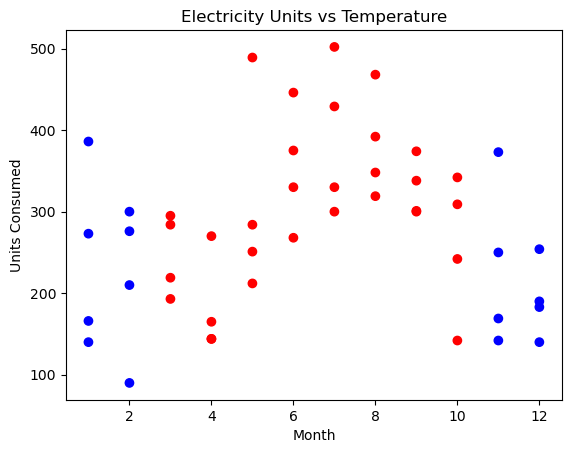

[1 1 1 1 0]
Accuracy: 1.0


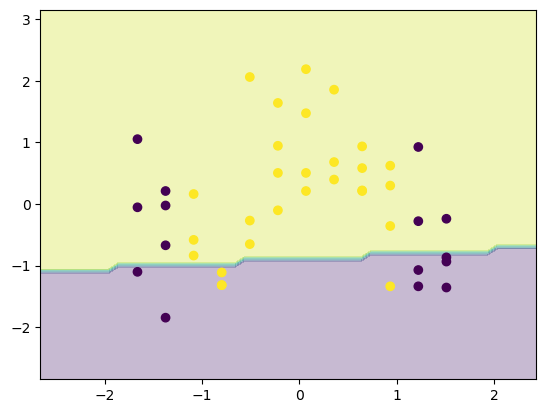

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("unit-non-acC.csv", sep="\t")

df['MONTH'] = df['MONTH'].map({
'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12
})

df['TEMP'] = df['TEMP'].map({'HOT':1,'COLD':0})

x = df[['MONTH','UNIT']]
y = df['TEMP']

colors = df['TEMP'].map({1:'red',0:'blue'})

plt.scatter(df['MONTH'], df['UNIT'], c=colors)
plt.xlabel("Month")
plt.ylabel("Units Consumed")
plt.title("Electricity Units vs Temperature")
plt.show()

x_train, x_test, y_train, y_test = train_test_split(
x, y, test_size=0.1, random_state=42
)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = LogisticRegression()

model.fit(x_train, y_train)

x_set, y_set = x_train, y_train

x1, x2 = np.meshgrid(
    np.arange(x_set[:,0].min()-1, x_set[:,0].max()+1, 0.1),
    np.arange(x_set[:,1].min()-1, x_set[:,1].max()+1, 0.1)
)

plt.contourf(
    x1, x2,
    model.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
    alpha=0.3
)

plt.scatter(x_set[:,0], x_set[:,1], c=y_set)

predictions = model.predict(x_test)

print(predictions)

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)
#end

In [4]:
month = int(input("Enter month number (1-12): "))
units = float(input("Enter units consumed: "))

new_data = [[month, units]]

new_data = scaler.transform(new_data)

prediction = model.predict(new_data)

prob = model.predict_proba(new_data)

print("Probability COLD:", prob[0][0])
print("Probability HOT:", prob[0][1])

Enter month number (1-12):  5
Enter units consumed:  400


Probability COLD: 0.15386465183578768
Probability HOT: 0.8461353481642123


E:\AnaConda\envs\model-test\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
import pickle

pickle.dump(model, open('model-2.pkl', 'wb'))